# RAPID-MFA 15a: Trouble shooting: initial stock with a stock driven model using a different survival curve

## Descriptions

This variant of the stock driven model allows to solve the _initial stocks problem_, which represents any stocks that are already existing in the system prior to the time series are accounted for, because the model assumes that the initial inflow starts building up the stock from zero. 

In this case, the model assumes that the initial stock all belong to the first year in the time series, distorting the following cohorts. This solution provides with a _unique survival curve_ for the first year stock, which deprecates faster than the rest.

### Exogenous variables
__Inflows:__ Railway data of Japan from _Tanikawa, H., Fishman, T., Okuoka, K., & Sugimoto, K. (2015). The weight of society over time and space: A comprehensive account of the construction material stock of Japan, 1945–2010. Journal of Industrial Ecology, 19(5), 778-791._

__Survival curve:__ mock values. Normal distribution. chosen to exemplify that the model works even in a case in which survival in year 0 is not 100%, i.e. there is already some outflow (throughput) from each inflow in its year of occurance.

### Notes
This example uses Normal distribution survival curves, but they can be replaced with any other curves.

### Relations with other RAPID-MFA codes
- `RAPID-MFA-2: The stock driven model`: The modelling steps are following those in this notebook.
- `RAPID-MFA-14: Troubleshooting the initial stock, flow driven model`: allows to solve the initial stock problem, but using a flow driven model instead.
- `RAPID-MFA 15b: Trouble shooting: initial stock with a stock driven model using leaching model`: is an alternative solution using the stock driven model to the same initial stock problem.
- `RAPID-MFA 15c: Trouble shooting: initial stock with a stock driven model`: is an alternative solution using the stock driven model to the same initial stock problem.

### Version, licence, and how to cite

Version 2026.7 - check the [RAPID MFA GitHub repository](https://github.com/TomerFishman/RAPID-MFA/) for changes, history, and updates.

This code was created and is maintained by the [RAPID MFA development team](https://github.com/TomerFishman/RAPID-MFA/tree/master#contributors-and-acknowledgements).

This notebook is <a href="https://creativecommons.org/licenses/by-nc/4.0"><img src="https://mirrors.creativecommons.org/presskit/buttons/88x31/png/by-nc.png" alt="CC-BY-NC" width="70"> CC-BY-NC</a>, meaning you can - and should! - freely reuse and adapt this code for noncommercial purposes __as long as you attribute this source__. 

## 1. Load libraries

In [ ]:
# %% 1. Load libraries
import numpy as np
import pandas as pd
import scipy.stats

## 2. Define example input data

In [ ]:
# %% 2. Define example input data
input_data = pd.Series([3648714.685, 3650304.605, 3652889.659, 3655055.855, 3655772.411, 3662912.35, 
                        3663887.175, 3670963.548, 3678930.998, 3668618.801, 3672909.848, 3674826.182,
                        3664671.192, 3673137.674, 3799949.102, 3792669.285, 3790034.365, 3777331.215,
                        3769431.593, 3753899.973, 3751656.137, 3733914.943, 3750868.872, 3768687.714,
                        3779471.855, 3867815.975, 3869118.191, 3875078.363, 3879239.156, 3883067.295,
                        3885778.279, 3898386.394, 4079394.532, 4077609.408, 4069241.351, 4057790.434,
                        4052450.883, 3979092.586, 4007890.682, 3967878.751, 3972743.035, 3979799.233,
                        3977730.399, 3979281.08, 3987864.764, 3976941.809, 3985063.413, 4028347.781,
                        4033346.479, 4037376.746, 4045015.573, 4043855.96, 4064250.081, 4061856.096,
                        4082347.234, 4089728.633, 4080102.939, 4071482.315, 4074341.147, 4075275.163,
                        4099241.12, 4131764.257], 
                        name = "stocks",
                        index = [1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959,
                                1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969,
                                1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979,
                                1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989,
                                1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999,
                                2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009,
                                2010, 2011]) 

# Parameters for the survival curve
ages = range(0, len(input_data))
mean = 30
std_dev = 10

# create the survival curve
survival_curve = scipy.stats.norm.sf(ages, loc=mean, scale=std_dev)

## 3. Run the stock-driven model

The steps from hereon are a repetition of notebook 2, but with different input data. If you want a more detailed account on how to do this, see notebook 2.

In [ ]:
# %% 3. Run the stock-driven model
units = {'time_interval': 'year', 
         'flows': 'kg/year', 
         'stocks': 'kg'}

timeframes = cohorts = input_data.index  # timeframes are the "snapshots" of the system in every time interval, while cohorts are the inflows that enter the system in every time interval. They are the same because we have one inflow per time interval.
time_interval = 1
cohort_stop = (cohorts[-1] + time_interval)  # because of exclusive slicing in python, an extra time interval is required
mfa_system = pd.DataFrame(index=timeframes, columns = ['stocks', 
                                                         'inflows', 
                                                         'outflows', 
                                                         'stock_changes'])

mfa_system['stocks'] = input_data

# create survival curves matrix filled with zeros
survival_curves_matrix = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)

# and populate that matrix
for cohort in cohorts:
    # at each iteration, shift the survival curve and fill the next column of the survival curves matrix with the shifted survival curve from the diagonal downwards.
    survival_curves_matrix.loc[cohort: , cohort] = survival_curve[0 : cohort_stop - cohort]
   
# initialize the cohort_survival_matrix filled with zeros
cohorts_survival_matrix = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)

# And populate it
for cohort in cohorts:
    # calculate the inflow of the time-th year
    mfa_system.loc[cohort, 'inflows'] = (
        mfa_system.loc[cohort, 'stocks'] - cohorts_survival_matrix.loc[cohort, : cohort - 1].sum()
    ) / survival_curves_matrix.loc[cohort, cohort]
    # now that the time-th inflow is known, scale the shifted survival curve with this inflow
    cohorts_survival_matrix.loc[:, cohort] = survival_curves_matrix.loc[:, cohort] * mfa_system.loc[cohort, 'inflows']
    
mfa_system["stock_changes"] = np.diff(mfa_system["stocks"], prepend=0)
mfa_system["outflows"] = mfa_system["inflows"] - mfa_system["stock_changes"]

## 4. Identify the initial stock issue
To identify the initial stocks before the year 1950, we can visualize the stocks by cohorts

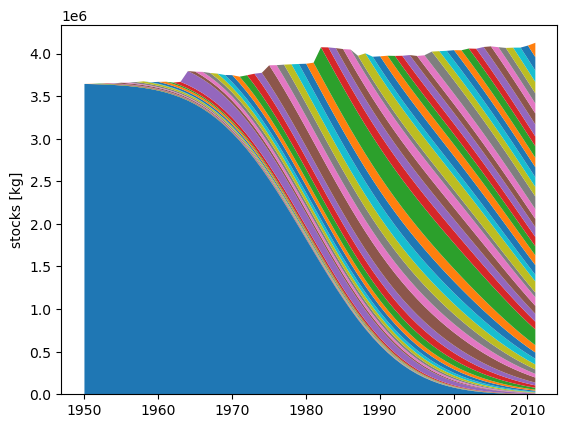

In [4]:
# plot stocks by cohorts
ax = cohorts_survival_matrix.plot(kind="area", stacked=True, legend=False, lw=0, ylabel="stocks [kg]")

## 5. Solving the initial stock issue

In [5]:
# %% treating the initial stock problem with a unique survival curve for cohort 0

# Geometrically distributed survival curve for cohort 0, assumes 5% of the initial stock becomes outflow every year
curve_deprecation = 0.05
survival_curves_matrix.loc[cohorts[0]: , cohorts[0]] = scipy.stats.geom.sf(range(len(timeframes)), curve_deprecation)

# Now create a new cohorts survival matrix and recalculate the inflows with the new survival curve
cohorts_survival_matrix = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)

# And populate it
for cohort in cohorts:
    # calculate the inflow of the time-th year
    mfa_system.loc[cohort, 'inflows'] = (
        mfa_system.loc[cohort, 'stocks'] - cohorts_survival_matrix.loc[cohort, : cohort - 1].sum()
    ) / survival_curves_matrix.loc[cohort, cohort]
    # now that the time-th inflow is known, scale the shifted survival curve with this inflow
    cohorts_survival_matrix.loc[:, cohort] = survival_curves_matrix.loc[:, cohort] * mfa_system.loc[cohort, 'inflows']

In [6]:
# %% 6. Recalculate the MFA system
mfa_system["stock_changes"] = np.diff(mfa_system["stocks"], prepend=0)
mfa_system["outflows"] = mfa_system["inflows"] - mfa_system["stock_changes"]

# %% 7. View the full MFA system
mfa_system_with_units = mfa_system.rename(columns={"stocks" : 'stocks [' + units['stocks'] + ']', 
                                                    "inflows" : 'inflows [' + units['flows'] + ']', 
                                                    "outflows" : 'outflows [' + units['flows'] + ']', 
                                                    "stock_changes" : 'stock_changes [' + units['flows'] + ']'})

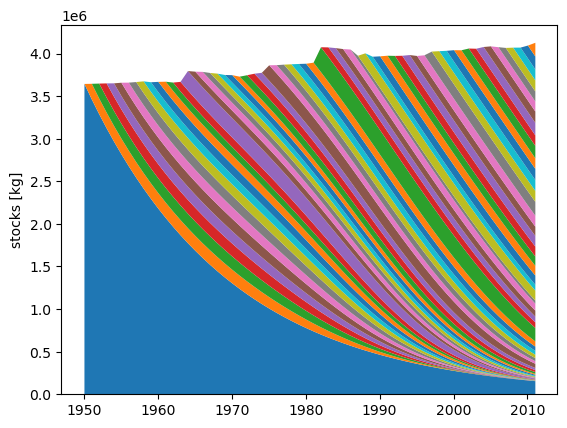

In [7]:
ax = cohorts_survival_matrix.plot(kind="area", stacked=True, legend=False, lw=0, ylabel="stocks [kg]")

## 5. Concluding remarks
Substantial outflows now occur from the start, addressing that part of the problem. These results appear credible and allow interpretation: in this case, most inflows are for maintenance and replacing old stocks that exit the system. This is partly due to the stock_changes fluctuating around zero, which is specific to this data set. The volatility in inflows reflects sudden increases or decreases in stocks, as shown by the stock changes. These represent individual stock expansions or reductions in specific years.